# libcbm run of tutorial 6 from CBM-CFS3

In [1]:
import os, json
import pandas as pd
%matplotlib inline

Import the required packages from libcbm

    - sit_cbm_factory: a module for initializing the CBM model from the CBM Standard import tool format
    - cbm_simulator: simulates the sit dataset using the CBM model
    - libcbm.resources: gets files for tutorial 2 that are bundled in libcbm


In [2]:
from libcbm.input.sit import sit_cbm_factory
from libcbm.model.cbm import cbm_simulator
from libcbm.model.cbm.cbm_output import CBMOutput
from libcbm import resources

## Setup
Load the standard import tool configuration at the specified path.  This configuration encompasses the data source for the various sit inputs (sit_inventory, sit_classifiers etc.) and also the relationships of classifiers, and disturbance types to the default CBM parameters.

In [3]:
config_path = os.path.join(resources.get_test_resources_dir(), "cbm3_tutorial6", "sit_config.json")
sit = sit_cbm_factory.load_sit(config_path)

Initialize and validate the inventory in the sit dataset

In [4]:
classifiers, inventory = sit_cbm_factory.initialize_inventory(sit)

Initialize an instance of the CBM model

Create storage and a function for storing CBM simulation results.  This particular implementation appends timestep results for each step into a running DataFrame which is stored in memory.

In [5]:
cbm_output = CBMOutput(
    classifier_map=sit.classifier_value_names
)

## Simulation

In [6]:
with sit_cbm_factory.initialize_cbm(sit) as cbm:
    # Create a function to apply rule based disturbance events and transition rules based on the SIT input
    rule_based_processor = sit_cbm_factory.create_sit_rule_based_processor(sit, cbm)
    # The following line of code spins up the CBM inventory and runs it through 200 timesteps.
    cbm_simulator.simulate(
        cbm,
        n_steps              = 200,
        classifiers          = classifiers,
        inventory            = inventory,
        pre_dynamics_func    = rule_based_processor.pre_dynamics_func,
        reporting_func       = cbm_output.append_simulation_result
    )

RuntimeError: b'invalid unordered_map<K, T> key'

## Pool Results

In [7]:
pi = cbm_output.pools.to_pandas().merge(cbm_output.classifiers.to_pandas())

In [8]:
list(pi)

['identifier',
 'timestep',
 'Input',
 'SoftwoodMerch',
 'SoftwoodFoliage',
 'SoftwoodOther',
 'SoftwoodCoarseRoots',
 'SoftwoodFineRoots',
 'HardwoodMerch',
 'HardwoodFoliage',
 'HardwoodOther',
 'HardwoodCoarseRoots',
 'HardwoodFineRoots',
 'AboveGroundVeryFastSoil',
 'BelowGroundVeryFastSoil',
 'AboveGroundFastSoil',
 'BelowGroundFastSoil',
 'MediumSoil',
 'AboveGroundSlowSoil',
 'BelowGroundSlowSoil',
 'SoftwoodStemSnag',
 'SoftwoodBranchSnag',
 'HardwoodStemSnag',
 'HardwoodBranchSnag',
 'CO2',
 'CH4',
 'CO',
 'NO2',
 'Products',
 'Species',
 'Site_quality',
 'Forest_type']

<Axes: xlabel='Year'>

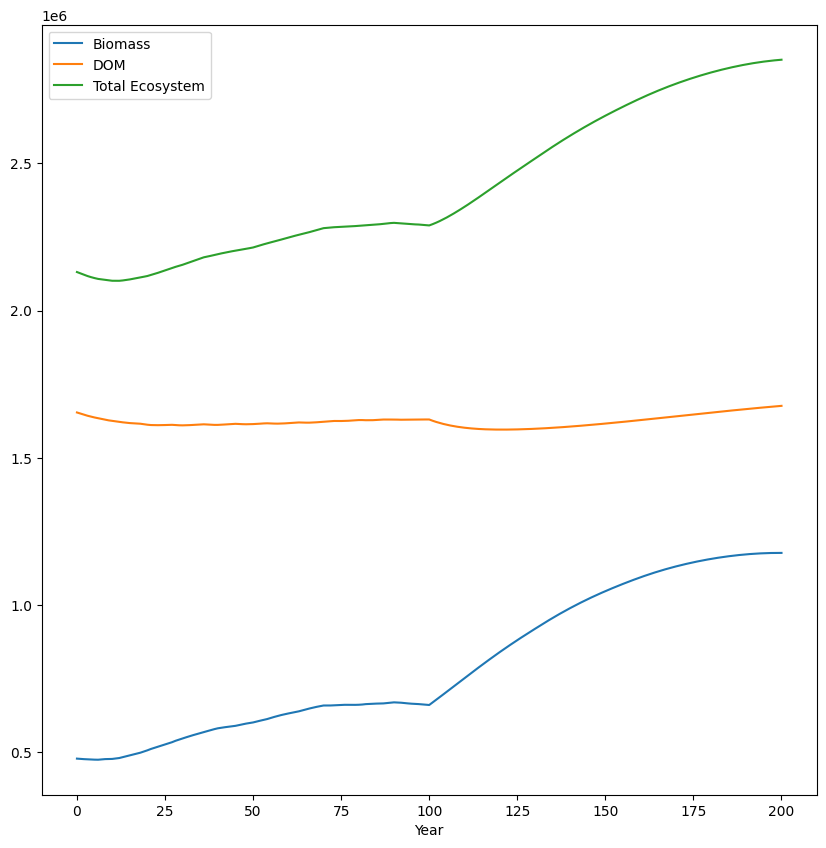

In [9]:
biomass_pools = ['SoftwoodMerch','SoftwoodFoliage', 'SoftwoodOther', 'SoftwoodCoarseRoots', 'SoftwoodFineRoots',
                 'HardwoodMerch', 'HardwoodFoliage', 'HardwoodOther', 'HardwoodCoarseRoots', 'HardwoodFineRoots']

dom_pools = ['AboveGroundVeryFastSoil', 'BelowGroundVeryFastSoil', 'AboveGroundFastSoil', 'BelowGroundFastSoil',
             'MediumSoil', 'AboveGroundSlowSoil', 'BelowGroundSlowSoil', 'SoftwoodStemSnag', 'SoftwoodBranchSnag',
             'HardwoodStemSnag', 'HardwoodBranchSnag']

biomass_result = pi[['timestep']+biomass_pools]
dom_result = pi[['timestep']+dom_pools]
total_eco_result = pi[['timestep']+biomass_pools+dom_pools]

annual_carbon_stocks = pd.DataFrame(
    {
        "Year": pi["timestep"],
        "Biomass": pi[biomass_pools].sum(axis=1),
        "DOM": pi[dom_pools].sum(axis=1),
        "Total Ecosystem": pi[biomass_pools+dom_pools].sum(axis=1)})

annual_carbon_stocks.groupby("Year").sum().plot(figsize=(10,10))

## State Variable Results

In [ ]:
si = cbm_output.state.to_pandas()

In [ ]:
si.head()

In [ ]:
state_variables = ['timestep','last_disturbance_type', 'time_since_last_disturbance', 'time_since_land_class_change',
 'growth_enabled', 'enabled', 'land_class', 'age', 'growth_multiplier', 'regeneration_delay']
si[state_variables].groupby('timestep').mean().plot(figsize=(10,10))

## Flux Indicators

In [ ]:
fi = cbm_output.flux.to_pandas()

In [ ]:
fi.head()

In [ ]:
annual_process_fluxes = [
    'DecayDOMCO2Emission',
    'DeltaBiomass_AG',
    'DeltaBiomass_BG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput',
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir']


In [ ]:
fi[["timestep"]+annual_process_fluxes].groupby("timestep").sum().plot(figsize=(15,10))

## Disturbance Statistics

In [ ]:
rule_based_processor.sit_event_stats_by_timestep[1]

## Appendix

### SIT source data

In [ ]:
sit.sit_data.age_classes

In [ ]:
sit.sit_data.inventory

In [ ]:
sit.sit_data.classifiers

In [ ]:
sit.sit_data.classifier_values

In [ ]:
sit.sit_data.disturbance_types

In [ ]:
sit.sit_data.yield_table

In [ ]:
sit.sit_data.disturbance_events

In [ ]:
sit.sit_data.transition_rules

In [ ]:
print(json.dumps(sit.config, indent=4, sort_keys=True))